In [1]:
#!pip install -U datasets
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

/opt/anaconda3/envs/python_project/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
job_counts = df["job_title_short"].value_counts().sort_values(ascending=False)
print(job_counts)

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64


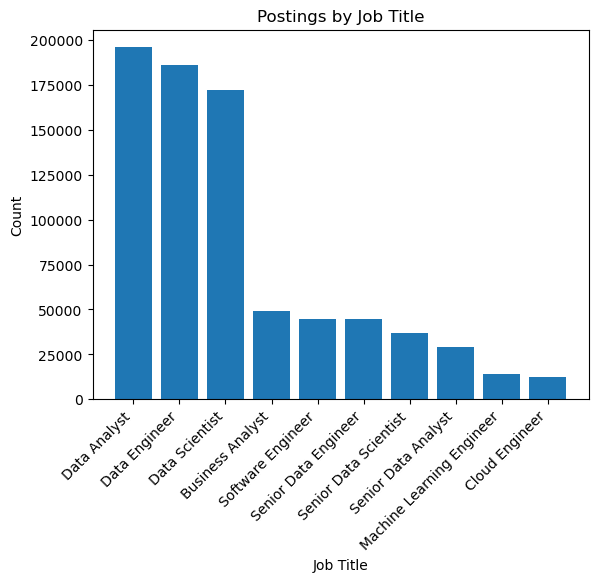

In [3]:
plt.bar(job_counts.index, job_counts.values)
plt.title("Postings by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [4]:
job_counts = df["job_title_short"].value_counts()
print(job_counts)

job_title_short
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Business Analyst              49063
Software Engineer             44929
Senior Data Engineer          44563
Senior Data Scientist         36957
Senior Data Analyst           29216
Machine Learning Engineer     14080
Cloud Engineer                12331
Name: count, dtype: int64


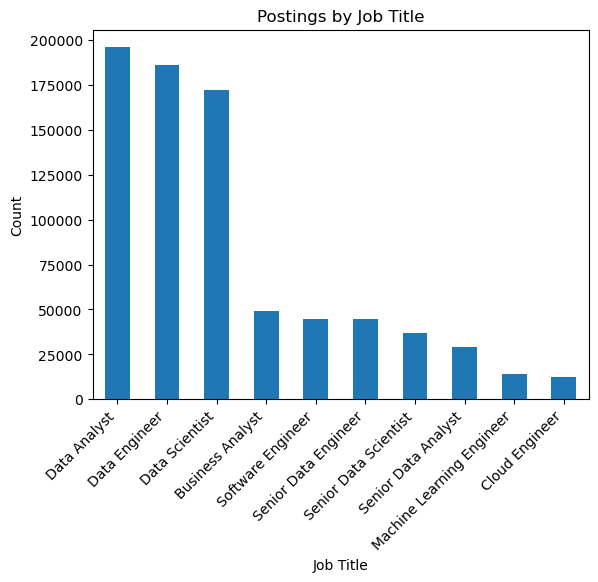

In [5]:
# Do it like this because it's better than above representation.
job_counts.plot(kind="bar")

plt.title("Postings by Job Title")
plt.xlabel("Job Title")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

In [6]:
df[["job_posted_date", "salary_year_avg"]].dropna(subset=["salary_year_avg"])

,job_posted_date,salary_year_avg
28,2023-08-01 13:37:57,109500.0
77,2023-06-26 14:22:54,140000.0
92,2023-02-21 13:29:59,120000.0
100,2023-07-31 13:01:18,228222.0
109,2023-10-12 13:02:19,89000.0
...,...,...
785624,2023-08-31 06:02:16,139216.0
785641,2023-01-04 16:36:07,150000.0
785648,2023-04-12 06:02:51,221875.0
785682,2023-03-04 06:16:08,157500.0


<Axes: xlabel='job_posted_date'>

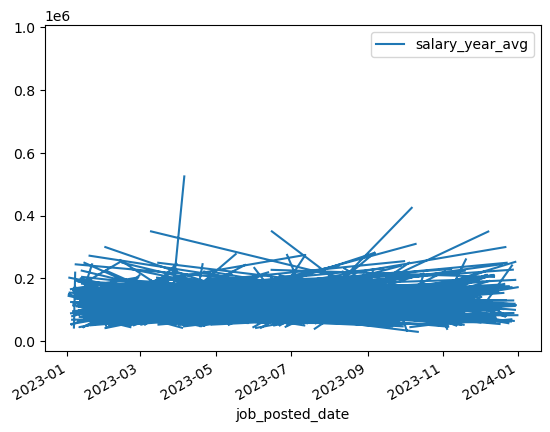

In [7]:
df.plot(x="job_posted_date", y="salary_year_avg", kind="line")

<Axes: >

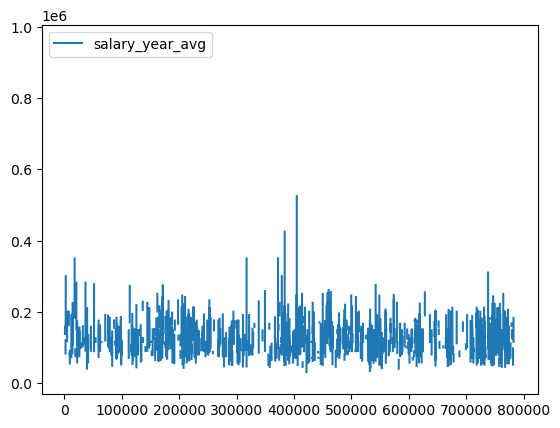

In [8]:
df.plot(y='salary_year_avg', kind='line')

In [9]:
# get the median job salary
job_salary = df.groupby("job_title_short")["salary_year_avg"].median().sort_values(ascending=True)
job_salary

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Software Engineer             99150.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Data Engineer                125000.0
Data Scientist               127500.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Name: salary_year_avg, dtype: float64

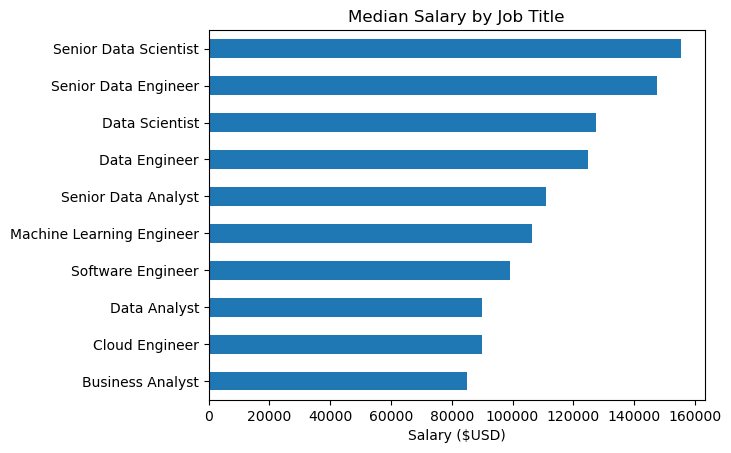

In [10]:
job_salary.plot(kind="barh")
# Customize the chart
plt.xlabel('Salary ($USD)')
plt.ylabel('')
plt.title('Median Salary by Job Title')

# Show the bar chart
plt.show()

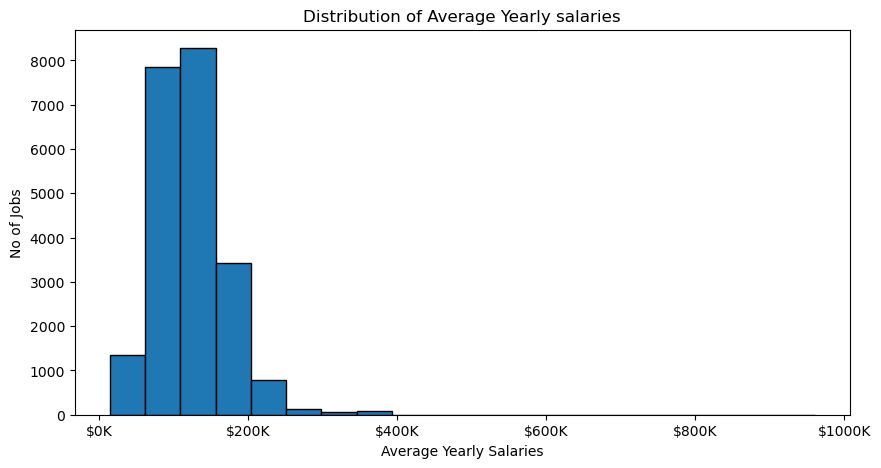

In [11]:
from matplotlib.ticker import FuncFormatter

# Drop rows with NA values in 'salary_year_avg' column
df_na = df.dropna(subset=["salary_year_avg"])

# Define the formatter function
def to_k(x, pos):
    """Convert number to string with K as thousands."""
    return f"${int(x/1000)}K"

# Create formatter using FuncFormatter
formatter = FuncFormatter(to_k)

# Create histogram
plt.figure(figsize=(10, 5))
plt.hist(df_na["salary_year_avg"], bins=20, edgecolor="black")

# Set title and labels
plt.title("Distribution of Average Yearly salaries")
plt.xlabel("Average Yearly Salaries")
plt.ylabel("No of Jobs")

# Apply the formatter to x-axis
plt.gca().xaxis.set_major_formatter(formatter)

# Show the plot
plt.show()
